# Experiment 4 — feature robustness, missingness, and conservative engineering
Unchanged Experiment 2 LightGBM/XGBoost configurations and exact existing folds. No hyperparameter tuning, external data, leaderboard-based selection, or arbitrary polynomial expansion.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
ablation = pd.read_csv(ROOT / 'reports/feature_ablation.csv')
missingness = pd.read_csv(ROOT / 'reports/missingness_diagnostics.csv')
missing_experiments = pd.read_csv(ROOT / 'reports/missingness_experiments.csv')
engineering = pd.read_csv(ROOT / 'reports/feature_engineering.csv')
robustness = pd.read_csv(ROOT / 'reports/feature_robustness.csv')
analysis = json.loads((ROOT / 'reports/feature_robustness_analysis.json').read_text())

The complete experiment is reproducible with `uv run diagnose-features`. The notebook reads checkpointed results because regeneration fits more than 100 fold models and performs 500 full-size paired bootstrap resamples.

## Part 1 — leave-one-feature-out ablations

In [2]:
ablation[[
    'experiment', 'oof_auc', 'delta_vs_raw_lightgbm', 'mean_fold_auc', 'std_fold_auc',
    'fold_1_auc', 'fold_2_auc', 'fold_3_auc', 'fold_4_auc', 'fold_5_auc'
]].style.format({c: '{:.6f}' for c in ablation.columns if 'auc' in c or c.startswith('delta')})

,experiment,oof_auc,delta_vs_raw_lightgbm,mean_fold_auc,std_fold_auc,fold_1_auc,fold_2_auc,fold_3_auc,fold_4_auc,fold_5_auc
0,full_raw_control,0.960604,0.000000,0.960605,0.000769,0.959638,0.960520,0.961029,0.961642,0.960196
1,drop_age,0.960282,-0.000321,0.960284,0.000986,0.959334,0.959276,0.960866,0.961558,0.960385
2,drop_daily_screen_time_hours,0.949218,-0.011386,0.949216,0.001052,0.949491,0.947708,0.949719,0.950465,0.948700
3,drop_social_media_hours,0.953458,-0.007145,0.953462,0.000970,0.952636,0.952546,0.953635,0.954948,0.953545
4,drop_gaming_hours,0.959375,-0.001229,0.959377,0.000466,0.959103,0.959040,0.959542,0.960126,0.959076
5,drop_work_study_hours,0.958731,-0.001873,0.958735,0.000829,0.957410,0.958885,0.959401,0.959435,0.958544
6,drop_sleep_hours,0.960196,-0.000408,0.960196,0.000887,0.959227,0.959462,0.960725,0.961377,0.960187
7,drop_notifications_per_day,0.951921,-0.008683,0.951921,0.001368,0.950873,0.950193,0.952673,0.953559,0.952306
8,drop_app_opens_per_day,0.953132,-0.007472,0.953134,0.001370,0.952184,0.951247,0.954017,0.954535,0.953685
9,drop_weekend_screen_time,0.950287,-0.010317,0.950299,0.000800,0.949918,0.949384,0.950593,0.950097,0.951503


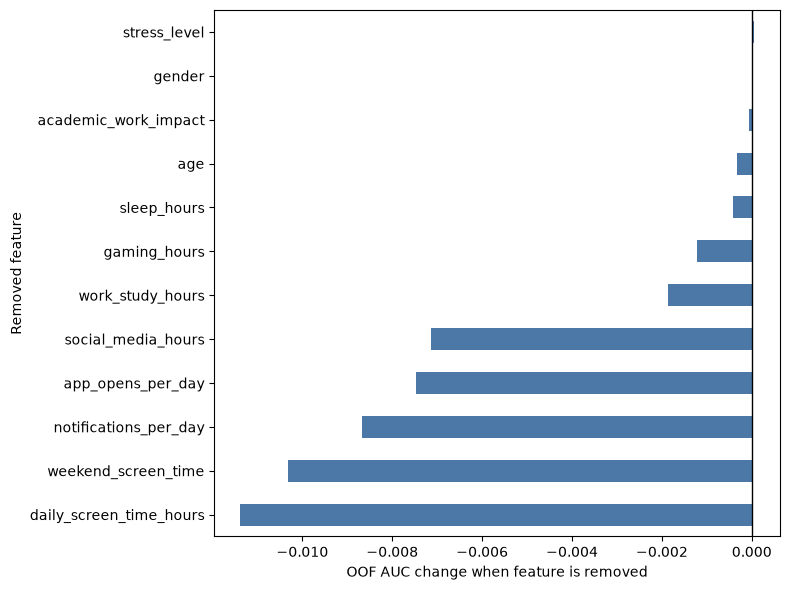

In [3]:
plot_data = ablation.iloc[1:].sort_values('delta_vs_raw_lightgbm')
ax = plot_data.plot.barh(x='features', y='delta_vs_raw_lightgbm', legend=False, figsize=(8, 6), color='#4C78A8')
ax.axvline(0, color='black', linewidth=1)
ax.set(xlabel='OOF AUC change when feature is removed', ylabel='Removed feature')
plt.tight_layout()

Daily screen time, weekend screen time, notifications, app opens, and social-media hours make the largest marginal contributions. Tiny gains from dropping gender or stress level should not be read as causal or sufficient evidence for removal.

## Part 2 — missingness diagnostics

In [4]:
missingness.sort_values('absolute_target_rate_delta', ascending=False).style.format({
    'train_missing_rate': '{:.4%}', 'test_missing_rate': '{:.4%}',
    'test_minus_train_missing_rate': '{:+.4%}',
    'target_rate_missing': '{:.4%}', 'target_rate_present': '{:.4%}',
    'target_rate_missing_minus_present': '{:+.4%}',
    'absolute_target_rate_delta': '{:.4%}',
})

,feature,train_missing_rate,test_missing_rate,test_minus_train_missing_rate,target_rate_missing,target_rate_present,target_rate_missing_minus_present,absolute_target_rate_delta,meaningful_at_0.003,n_missing_train
5,sleep_hours,6.4336%,7.5784%,+1.1448%,71.3377%,70.9153%,+0.4224%,0.4224%,True,44480
0,age,4.1843%,5.7840%,+1.5997%,71.3402%,70.9251%,+0.4151%,0.4151%,True,28929
7,app_opens_per_day,11.6739%,8.6753%,-2.9987%,71.2787%,70.8980%,+0.3807%,0.3807%,True,80710
1,daily_screen_time_hours,13.8644%,11.0657%,-2.7986%,71.1301%,70.9122%,+0.2178%,0.2178%,False,95854
8,weekend_screen_time,16.2089%,17.1099%,+0.9011%,71.0654%,70.9187%,+0.1467%,0.1467%,False,112063
3,gaming_hours,18.3435%,20.0539%,+1.7104%,71.0505%,70.9182%,+0.1324%,0.1324%,False,126821
4,work_study_hours,7.4516%,9.3746%,+1.9230%,71.0645%,70.9326%,+0.1319%,0.1319%,False,51518
6,notifications_per_day,9.7754%,11.5494%,+1.7740%,71.0242%,70.9336%,+0.0906%,0.0906%,False,67584
9,gender,4.1995%,4.7965%,+0.5970%,70.8790%,70.9452%,-0.0662%,0.0662%,False,29034
10,stress_level,7.9766%,6.6236%,-1.3530%,70.9001%,70.9461%,-0.0460%,0.0460%,False,55148


In [5]:
missing_experiments[[
    'experiment', 'n_added_features', 'oof_auc', 'log_loss',
    'delta_vs_raw_lightgbm', 'mean_fold_auc', 'std_fold_auc'
]].style.format({c: '{:.6f}' for c in ['oof_auc', 'log_loss', 'delta_vs_raw_lightgbm', 'mean_fold_auc', 'std_fold_auc']})

,experiment,n_added_features,oof_auc,log_loss,delta_vs_raw_lightgbm,mean_fold_auc,std_fold_auc
0,raw_control_no_explicit_indicators,0,0.960604,0.232012,0.000000,0.960605,0.000769
1,missing_indicators_all,12,0.960595,0.233563,-0.000009,0.960596,0.000857
2,missing_indicators_meaningful,3,0.960604,0.232012,0.000000,0.960605,0.000769


The predeclared meaningful-association threshold is an absolute 0.003 target-rate difference. It selects age, sleep hours, and app opens. Their explicit indicators exactly reproduce the native LightGBM result; all indicators slightly hurt. Missingness may reflect synthetic generation, but native missing-value routing already captures any useful signal.

## Part 3 — conservative engineered candidates

In [6]:
engineered_rows = engineering[engineering['experiment'].str.startswith(('individual_', 'combination_'))]
engineered_rows[[
    'experiment', 'features', 'oof_auc', 'log_loss', 'delta_vs_raw_lightgbm',
    'mean_fold_auc', 'std_fold_auc'
]].sort_values('oof_auc', ascending=False).style.format({
    c: '{:.6f}' for c in ['oof_auc', 'log_loss', 'delta_vs_raw_lightgbm', 'mean_fold_auc', 'std_fold_auc']
})

,experiment,features,oof_auc,log_loss,delta_vs_raw_lightgbm,mean_fold_auc,std_fold_auc
8,individual_leisure_screen_proxy,leisure_screen_proxy,0.960797,0.233728,0.000194,0.960798,0.000628
11,combination_all_positive,leisure_screen_proxy|entertainment_share_of_screen|total_entertainment_hours,0.960640,0.234416,0.000037,0.960643,0.000686
10,individual_entertainment_share_of_screen,entertainment_share_of_screen,0.960624,0.233426,0.000020,0.960626,0.000822
12,combination_positive_ratios,entertainment_share_of_screen,0.960624,0.233426,0.000020,0.960626,0.000822
7,individual_total_entertainment_hours,total_entertainment_hours,0.960611,0.232120,0.000008,0.960614,0.000597
3,individual_notifications_per_open,notifications_per_open,0.960591,0.231691,-0.000013,0.960593,0.000710
4,individual_opens_per_screen_hour,opens_per_screen_hour,0.960577,0.232035,-0.000027,0.960581,0.000613
9,individual_weekend_daily_screen_gap,weekend_daily_screen_gap,0.960414,0.233975,-0.000190,0.960413,0.001013
6,individual_weekend_vs_daily_screen,weekend_vs_daily_screen,0.960411,0.233851,-0.000193,0.960411,0.000820
5,individual_notifications_per_screen_hour,notifications_per_screen_hour,0.960051,0.242813,-0.000552,0.960053,0.001132


`leisure_screen_proxy = daily_screen_time_hours - work_study_hours` is the clear individual winner. This interpretation assumes work/study hours are a component of total screen time. Combining all three individually positive candidates performs worse than this feature alone, so the single-feature set proceeds to transfer testing.

## Part 4 — cross-model and blend robustness

In [7]:
robustness[[
    'model', 'features', 'oof_auc', 'log_loss', 'mean_fold_auc', 'std_fold_auc',
    'fold_1_auc', 'fold_2_auc', 'fold_3_auc', 'fold_4_auc', 'fold_5_auc',
    'delta_vs_current_champion'
]].style.format({c: '{:.6f}' for c in robustness.columns if 'auc' in c or c in ['log_loss', 'delta_vs_current_champion']})

,model,features,oof_auc,log_loss,mean_fold_auc,std_fold_auc,fold_1_auc,fold_2_auc,fold_3_auc,fold_4_auc,fold_5_auc,delta_vs_current_champion
0,LightGBM,leisure_screen_proxy,0.960797,0.233728,0.960798,0.000628,0.960139,0.960652,0.960627,0.961841,0.960731,-0.000247
1,XGBoost,leisure_screen_proxy,0.960905,0.230040,0.960907,0.000675,0.960006,0.960748,0.961155,0.961859,0.960769,-0.000139
2,Blend50_50,leisure_screen_proxy,0.961326,0.228840,0.961328,0.000648,0.960478,0.961191,0.961462,0.962283,0.961225,0.000282


In [8]:
pd.Series(analysis['bootstrap_vs_current_champion'], name='engineered blend minus E3 blend').to_frame()

,engineered blend minus E3 blend
mean,0.000282
ci_95_lower,0.000238
ci_95_upper,0.000326
proportion_positive,1.000000
n_resamples,500.000000
seed,42.000000


The feature improves both unchanged component models and raises their 50/50 blend to 0.961326, +0.000282 over E3. The paired 500-resample interval is [0.000238, 0.000326], positive in every resample. This satisfies the predeclared robustness gate, so `submission_04_features.csv` was generated and validated locally. It was not submitted.